# Step 4 — P300 ERP Verification (Subject 01)

## Objective

This notebook verifies that the physiological **P300 event-related potential (ERP)**
is present in the already-preprocessed, artifact-rejected EEG epochs for
**Subject 01** of the BNCI2014-008 dataset.

Scope of this notebook:

- Load the clean Subject 01 epochs produced by `src/preprocessing/pipeline.py`.
- Separate epochs into **Target** and **NonTarget** classes and report the
  counts that survived artifact rejection.
- Compute the Target and NonTarget ERPs (MNE `Evoked` objects).
- Plot the two ERPs overlaid at the Pz (or closest parietal) channel, with the
  stimulus onset (0 ms) and the 300–500 ms window clearly marked.
- Quantify peak latency and 300–500 ms mean amplitude for each condition.
- Run a P300 sanity check: Target should generally show a larger positive
  deflection than NonTarget in the P300 time range.
- Summarize the results in a Section 6 table and save the ERP objects,
  summary table, and figure to disk.

## 1. Imports

In [11]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

## 2. Project Paths / Configuration

Paths are resolved **relative to this notebook's location**, not hard-coded to
any particular machine or OS. The notebook assumes the standard project
layout described in `README.md`:

```
<project_root>/
├── data/preprocessed/subject_01_clean-epo.fif
├── notebooks/erp_analysis.ipynb   <- this notebook
├── results/erp/subject_01/
└── figures/erp/subject_01/
```

The `results/erp/subject_01/` and `figures/erp/subject_01/` output
directories are created if they do not already exist. No existing project
convention for ERP outputs was found in the provided files, so this
notebook introduces one, following the pattern already used by
`src/preprocessing/pipeline.py` (which writes to `data/preprocessed/`).

In [2]:
# Discover the project root robustly: this notebook lives in <project_root>/notebooks/,
# so its parent directory is the project root. Falls back to the current working
# directory if the notebook is executed in an environment where __file__/cwd
# already IS the project root (e.g. some notebook runners).
try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent  # some IDEs set this
except NameError:
    NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

SUBJECT_ID = "subject_01"

CLEAN_EPOCHS_PATH = PROJECT_ROOT / "data" / "preprocessed" / "subject_01_clean-epo.fif"

RESULTS_DIR = PROJECT_ROOT / "results" / "erp" / SUBJECT_ID
FIGURES_DIR = PROJECT_ROOT / "figures" / "erp" / SUBJECT_ID
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_ERP_PATH = RESULTS_DIR / "target_erp-ave.fif"
NONTARGET_ERP_PATH = RESULTS_DIR / "nontarget_erp-ave.fif"
SUMMARY_CSV_PATH = RESULTS_DIR / "erp_summary.csv"
FIGURE_PATH = FIGURES_DIR / "target_vs_nontarget_pz.png"

# P300 analysis window, as required by the Step 4 task specification.
P300_WINDOW = (0.300, 0.500)  # seconds

print("Project root:      ", PROJECT_ROOT)
print("Clean epochs file: ", CLEAN_EPOCHS_PATH, "(exists:", CLEAN_EPOCHS_PATH.exists(), ")")
print("Results directory: ", RESULTS_DIR)
print("Figures directory: ", FIGURES_DIR)

Project root:       C:\Users\USER\EEG project\eeg-p300-recognition-assessment
Clean epochs file:  C:\Users\USER\EEG project\eeg-p300-recognition-assessment\data\preprocessed\subject_01_clean-epo.fif (exists: True )
Results directory:  C:\Users\USER\EEG project\eeg-p300-recognition-assessment\results\erp\subject_01
Figures directory:  C:\Users\USER\EEG project\eeg-p300-recognition-assessment\figures\erp\subject_01


## 3. Load Subject 01 Clean Epochs

We load **exactly** the provided clean epochs file
(`data/preprocessed/subject_01_clean-epo.fif`). This file was produced by
`src/preprocessing/pipeline.py` (channel selection, 0.1–30 Hz band-pass,
epoching at -0.2 to 0.8 s, baseline correction, and peak-to-peak artifact
rejection). We do **not** regenerate or modify this file, and we analyze
Subject 01 only.

In [3]:
if not CLEAN_EPOCHS_PATH.exists():
    raise FileNotFoundError(
        f"Expected clean epochs file not found at {CLEAN_EPOCHS_PATH}. "
        "Step 4 must use the already-preprocessed Subject 01 epochs; "
        "this notebook does not regenerate them."
    )

epochs = mne.read_epochs(CLEAN_EPOCHS_PATH, preload=True, verbose=False)
print(epochs)

<EpochsFIF | 4200 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~65.9 MiB, data loaded,
 'NonTarget': 3500
 'Target': 700>


## 4. Dataset Sanity Check

Before separating conditions, we record the basic properties of the loaded
epochs: channel names, sampling rate, epoch time window, event IDs, and
signal units. This mirrors the "Verification Records" style already used in
`src/preprocessing/pipeline.py` and ensures Step 4 operates on data with the
expected shape and units.

In [4]:
from mne.io.constants import FIFF

print("=== Loaded Epochs Verification ===")
print(f"[Record] Channels ({len(epochs.ch_names)}): {epochs.ch_names}")
print(f"[Record] Sampling rate: {epochs.info['sfreq']:.1f} Hz")
print(f"[Record] Epoch window: {epochs.tmin:.3f} s to {epochs.tmax:.3f} s")
print(f"[Record] Number of time samples per epoch: {len(epochs.times)}")
print(f"[Record] event_id mapping: {epochs.event_id}")
print(f"[Record] Total retained epochs (Target + NonTarget): {len(epochs)}")

# Confirm EEG channel units are volts, matching the preprocessing pipeline's
# own unit verification. ERP amplitudes reported later are converted to
# microvolts (uV) for readability, since EEG is conventionally reported in uV.
eeg_picks = mne.pick_types(epochs.info, eeg=True, stim=False)
eeg_units = {epochs.info['chs'][idx]['unit'] for idx in eeg_picks}
units_are_volts = eeg_units == {FIFF.FIFF_UNIT_V}
print(f"[Record] EEG channel unit is volts (V): {units_are_volts}")
if not units_are_volts:
    print("[WARNING] EEG channels are not uniformly in volts. "
          "Amplitude values reported below may need reinterpretation.")

=== Loaded Epochs Verification ===
[Record] Channels (8): ['Fz', 'Cz', 'Pz', 'Oz', 'P3', 'P4', 'PO7', 'PO8']
[Record] Sampling rate: 256.0 Hz
[Record] Epoch window: -0.199 s to 0.801 s
[Record] Number of time samples per epoch: 257
[Record] event_id mapping: {'NonTarget': 1, 'Target': 2}
[Record] Total retained epochs (Target + NonTarget): 4200
[Record] EEG channel unit is volts (V): True


## 5. Separate Target and NonTarget Epochs

The clean epochs are separated into Target and NonTarget conditions using the event labels stored in the MNE Epochs object.

In [5]:
required_labels = {"Target", "NonTarget"}
missing_labels = required_labels - set(epochs.event_id.keys())
if missing_labels:
    raise ValueError(
        f"Expected event labels {required_labels} not found in epochs.event_id "
        f"({epochs.event_id}). Missing: {missing_labels}."
    )

target_epochs = epochs["Target"]
nontarget_epochs = epochs["NonTarget"]

print("Target epochs object:")
print(target_epochs)
print("\nNonTarget epochs object:")
print(nontarget_epochs)

Target epochs object:
<EpochsFIF | 700 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~11.0 MiB, data loaded,
 'Target': 700>

NonTarget epochs object:
<EpochsFIF | 3500 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~54.9 MiB, data loaded,
 'NonTarget': 3500>


## 6. Report Counts After Artifact Rejection

These counts represent the Target and NonTarget epochs retained after the preprocessing pipeline's artifact rejection. No additional rejection is applied in this notebook.

In [12]:
n_target = len(target_epochs)
n_nontarget = len(nontarget_epochs)
n_total = len(epochs)

print("=== Post-Artifact-Rejection Class Counts ===")
print(f"[Record] Target epochs:    {n_target}")
print(f"[Record] NonTarget epochs: {n_nontarget}")
print(f"[Record] Total epochs:     {n_total}")
target_fraction = n_target / n_total
print(f"[Record] Target fraction: {target_fraction:.1%}")

=== Post-Artifact-Rejection Class Counts ===
[Record] Target epochs:    700
[Record] NonTarget epochs: 3500
[Record] Total epochs:     4200
[Record] Target fraction: 16.7%


## 7. Compute Target and NonTarget ERPs

The Target and NonTarget epochs are averaged separately to obtain the corresponding ERP waveforms. MNE's Epochs.average() is used to create an Evoked object for each condition


In [13]:
# Compute the ERP for each condition by averaging its epochs.
target_evoked = target_epochs.average()
nontarget_evoked = nontarget_epochs.average()

# Label each Evoked object for clarity.
target_evoked.comment = "Target"
nontarget_evoked.comment = "NonTarget"

print(f"Target ERP:     {target_evoked}")
print(f"NonTarget ERP:  {nontarget_evoked}")

Target ERP:     <Evoked | 'Target' (average, N=700), -0.19922 – 0.80078 s, baseline -0.2 – 0 s, 8 ch, ~33 KiB>
NonTarget ERP:  <Evoked | 'NonTarget' (average, N=3500), -0.19922 – 0.80078 s, baseline -0.2 – 0 s, 8 ch, ~33 KiB>


## 8. Select Pz / Closest Parietal Channel

The P300 is typically strongest over midline-parietal scalp sites, with Pz being the preferred electrode for ERP analysis. The task requires the ERP comparison at Pz, or, if Pz is unavailable, the closest available parietal channel.

Selection logic:

1. If Pz is present in the epochs, use Pz.
2. Otherwise, calculate the distance between the available parietal channels and the standard Pz position, then select the closest channel.

In [9]:
PARIETAL_CANDIDATES = [
    "P1", "P2", "P3", "P4", "P5", "P6",
    "P7", "P8", "PO3", "PO4", "PO7", "PO8",
    "POz", "Oz"
]

def select_erp_channel(epochs):
    available = set(epochs.ch_names)

    # Use Pz directly when available.
    if "Pz" in available:
        return "Pz"

    # Otherwise calculate the closest available parietal/
    # parieto-occipital channel to Pz using standard 10-20 positions.
    montage = mne.channels.make_standard_montage("standard_1020")
    positions = montage.get_positions()["ch_pos"]

    target_pos = positions["Pz"]

    candidates = [
        ch for ch in PARIETAL_CANDIDATES
        if ch in available and ch in positions
    ]

    if not candidates:
        raise ValueError(
            "Pz is unavailable and no suitable parietal/"
            "parieto-occipital fallback channel was found."
        )

    distances = {
        ch: np.linalg.norm(positions[ch] - target_pos)
        for ch in candidates
    }

    selected = min(distances, key=distances.get)

    print(f"Pz unavailable.")
    print(f"Closest available parietal channel: {selected}")
    print(f"Distance to Pz: {distances[selected]:.4f}")

    return selected

## 9. Plot Target vs NonTarget ERP

The overlay plot below shows the Target and NonTarget ERP waveforms at the
selected channel, converted to microvolts (µV) for readability. It marks:

- a vertical dashed line at **0 ms** (stimulus onset),
- a shaded band over the **300–500 ms** P300 analysis window,
- axis labels with units, a legend, and a title,

so it can be used directly for project documentation / team discussion.

Figure saved to: C:\Users\USER\EEG project\eeg-p300-recognition-assessment\figures\erp\subject_01\target_vs_nontarget_pz.png


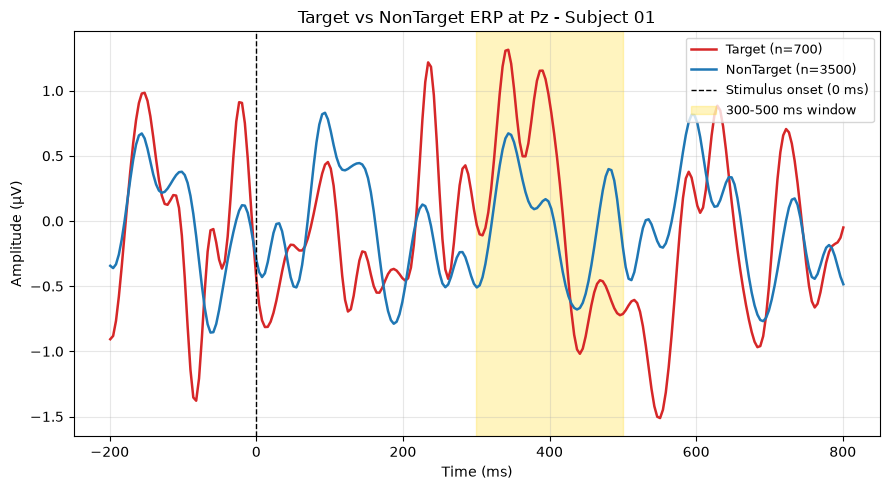

In [10]:
ch_idx = target_evoked.ch_names.index(selected_channel)

times_ms = target_evoked.times * 1000.0
target_uv = target_evoked.data[ch_idx] * 1e6      # V -> uV
nontarget_uv = nontarget_evoked.data[ch_idx] * 1e6  # V -> uV

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(times_ms, target_uv, label=f"Target (n={n_target})", color="tab:red", linewidth=1.8)
ax.plot(times_ms, nontarget_uv, label=f"NonTarget (n={n_nontarget})", color="tab:blue", linewidth=1.8)

# Stimulus onset marker.
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="Stimulus onset (0 ms)")

# 300-500 ms P300 analysis window, shaded for visibility.
ax.axvspan(P300_WINDOW[0] * 1000, P300_WINDOW[1] * 1000, color="gold", alpha=0.25,
           label="300-500 ms window")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude (\u00b5V)")
ax.set_title(f"Target vs NonTarget ERP at {selected_channel} - Subject 01")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()

fig.savefig(FIGURE_PATH, dpi=150)
print(f"Figure saved to: {FIGURE_PATH}")
plt.show()

## 10. Quantify 300–500 ms Mean Amplitude

The mean amplitude is computed over the exact 300–500 ms window using the
**actual time values stored in the Evoked object** (`evoked.times`), not
assumed sample indices, so the result is correct regardless of the sampling
rate. `Evoked.copy().crop()` selects the matching samples and we average
across that window at the selected channel.

In [14]:
def mean_amplitude_uv(evoked, channel, window):
    """Mean amplitude (uV) at `channel` within `window` (tmin, tmax) in seconds,
    using the Evoked object's own time values (mne crop() is inclusive of both
    edges and snaps to the nearest available sample)."""
    cropped = evoked.copy().crop(tmin=window[0], tmax=window[1])
    ch_idx_local = cropped.ch_names.index(channel)
    data_uv = cropped.data[ch_idx_local] * 1e6
    return float(np.mean(data_uv)), cropped.times[0], cropped.times[-1]

target_mean_amp, win_t0, win_t1 = mean_amplitude_uv(target_evoked, selected_channel, P300_WINDOW)
nontarget_mean_amp, _, _ = mean_amplitude_uv(nontarget_evoked, selected_channel, P300_WINDOW)

print("=== 300-500 ms Mean Amplitude ===")
print(f"[Record] Channel: {selected_channel}")
print(f"[Record] Actual window used: {win_t0*1000:.1f} ms to {win_t1*1000:.1f} ms "
      "(snapped to the nearest available samples)")
print(f"[Record] Target mean amplitude:    {target_mean_amp:.3f} uV")
print(f"[Record] NonTarget mean amplitude: {nontarget_mean_amp:.3f} uV")
print(f"[Record] Difference (Target - NonTarget): {target_mean_amp - nontarget_mean_amp:.3f} uV")

=== 300-500 ms Mean Amplitude ===
[Record] Channel: Pz
[Record] Actual window used: 300.8 ms to 500.0 ms (snapped to the nearest available samples)
[Record] Target mean amplitude:    0.129 uV
[Record] NonTarget mean amplitude: -0.009 uV
[Record] Difference (Target - NonTarget): 0.139 uV


## 11. Measure Peak Latency

**Implementation choice (not specified by the task):** the task requires
measuring peak latency but does not define the detection method. We use the
following reproducible method:

- For each condition (Target, NonTarget), search for the **maximum
  (most positive) amplitude** at the selected channel within a search
  window of **250–600 ms**. This window is centered on, and slightly wider
  than, the 300–500 ms analysis window so a peak near its edges is not
  artificially clipped, while still being restricted to the physiologically
  relevant P300 latency range (P300 peaks are typically reported
  approximately 250–500+ ms post-stimulus, extending toward 600 ms for
  P300b/slow responses).
- The peak latency is the time (ms) at which that maximum occurs.

This is a simple global-maximum search, not local-peak/derivative-based
detection, chosen for transparency and reproducibility. It is documented
here as an implementation choice, not a team-specified requirement.

In [16]:
PEAK_SEARCH_WINDOW = P300_WINDOW  # 300–500 ms

def peak_latency_amplitude(evoked, channel, window):
    """Return the maximum positive amplitude and its latency within window."""
    cropped = evoked.copy().crop(tmin=window[0], tmax=window[1])
    ch_idx = cropped.ch_names.index(channel)

    data_uv = cropped.data[ch_idx] * 1e6
    peak_idx = int(np.argmax(data_uv))

    return (
        float(cropped.times[peak_idx] * 1000.0),
        float(data_uv[peak_idx]),
    )

target_peak_lat_ms, target_peak_amp_uv = peak_latency_amplitude(
    target_evoked, selected_channel, PEAK_SEARCH_WINDOW
)

nontarget_peak_lat_ms, nontarget_peak_amp_uv = peak_latency_amplitude(
    nontarget_evoked, selected_channel, PEAK_SEARCH_WINDOW
)

print("=== Peak Latency (300–500 ms) ===")
print(f"[Record] Channel: {selected_channel}")
print(
    f"[Record] Target peak: {target_peak_amp_uv:.3f} µV "
    f"at {target_peak_lat_ms:.1f} ms"
)
print(
    f"[Record] NonTarget peak: {nontarget_peak_amp_uv:.3f} µV "
    f"at {nontarget_peak_lat_ms:.1f} ms"
)

=== Peak Latency (300–500 ms) ===
[Record] Channel: Pz
[Record] Target peak: 1.314 µV at 343.8 ms
[Record] NonTarget peak: 0.672 µV at 343.8 ms


## 12. P300 Sanity Check

The classic P300 pattern is a **larger positive deflection for Target
(oddball/relevant) stimuli than for NonTarget stimuli**, typically in the
300–500 ms range. We check this directly from the measured values above,
without altering labels, polarity, units, reference, preprocessing, or
timing to force a particular outcome. This is a verification check, not a
requirement to force the data to produce an expected result.

In [18]:
mean_amp_check_passed = target_mean_amp > nontarget_mean_amp
peak_amp_check_passed = target_peak_amp_uv > nontarget_peak_amp_uv

print("=== P300 Sanity Check ===")
print(
    f"[Record] Target 300-500ms mean ({target_mean_amp:.3f} uV) > "
    f"NonTarget 300-500ms mean ({nontarget_mean_amp:.3f} uV): "
    f"{mean_amp_check_passed}"
)
print(
    f"[Record] Target peak amplitude ({target_peak_amp_uv:.3f} uV) > "
    f"NonTarget peak amplitude ({nontarget_peak_amp_uv:.3f} uV): "
    f"{peak_amp_check_passed}"
)

sanity_check_result = (
    "EXPECTED_PATTERN"
    if mean_amp_check_passed and peak_amp_check_passed
    else "UNEXPECTED_PATTERN"
)

print(f"[Record] Overall P300 sanity check: {sanity_check_result}")

=== P300 Sanity Check ===
[Record] Target 300-500ms mean (0.129 uV) > NonTarget 300-500ms mean (-0.009 uV): True
[Record] Target peak amplitude (1.314 uV) > NonTarget peak amplitude (0.672 uV): True
[Record] Overall P300 sanity check: EXPECTED_PATTERN


## 13. Diagnostic Investigation (if the sanity check is unexpected)

If the sanity check above is `UNEXPECTED`, this section reports diagnostic
observations for the factors named by the task: labels, polarity, units,
reference, preprocessing, and timing. **No data is modified here** — this
is observation and reporting only. If the check passed, this section is
skipped.

In [19]:
if sanity_check_result == "UNEXPECTED_PATTERN":
    print("=== Diagnostic Investigation ===")

    # 1. Labels
    print(f"[Diagnostic] Event ID mapping: {epochs.event_id}")
    print(f"[Diagnostic] Target count: {n_target}, NonTarget count: {n_nontarget}")

    # 2. Polarity
    diff_uv = target_mean_amp - nontarget_mean_amp
    print(
        f"[Diagnostic] Target-minus-NonTarget mean amplitude (300-500ms): "
        f"{diff_uv:.3f} uV "
        f"({'positive' if diff_uv > 0 else 'negative or zero'})"
    )

    # 3. Units
    print(f"[Diagnostic] EEG units confirmed volts (V): {units_are_volts}")

    # 4. Reference
    print(
        f"[Diagnostic] Custom reference applied "
        f"(info['custom_ref_applied']): "
        f"{epochs.info.get('custom_ref_applied')}"
    )
    print(f"[Diagnostic] Bads listed in info: {epochs.info.get('bads')}")

    # 5. Preprocessing / epoch timing
    print(
        f"[Diagnostic] Epoch window in loaded file: "
        f"{epochs.tmin:.3f} to {epochs.tmax:.3f} s"
    )

## 14. Summary Table

In [ ]:
summary_rows = {
    "Subject": "subject_01",
    "Target epoch count": n_target,
    "NonTarget epoch count": n_nontarget,
    "Selected channel": selected_channel,
    "Channel is Pz": channel_is_pz,
    "Target peak latency (ms)": round(target_peak_lat_ms, 1),
    "Target peak amplitude (uV)": round(target_peak_amp_uv, 3),
    "NonTarget peak latency (ms)": round(nontarget_peak_lat_ms, 1),
    "NonTarget peak amplitude (uV)": round(nontarget_peak_amp_uv, 3),
    "Target mean amplitude 300-500ms (uV)": round(target_mean_amp, 3),
    "NonTarget mean amplitude 300-500ms (uV)": round(nontarget_mean_amp, 3),
    "Target - NonTarget mean amplitude (uV)": round(target_mean_amp - nontarget_mean_amp, 3),
    "Sanity check result": sanity_check_result,
    "Diagnostic note": (
        "None - sanity check passed as expected." if sanity_check_result == "EXPECTED_PATTERN"
        else "See Section 13 diagnostic investigation above."
    ),
}

summary_df = pd.DataFrame(list(summary_rows.items()), columns=["Metric", "Value"])
summary_df.to_csv(SUMMARY_CSV_PATH, index=False)

print(f"Summary table saved to: {SUMMARY_CSV_PATH}")
summary_df

Summary table saved to: C:\Users\USER\EEG project\eeg-p300-recognition-assessment\results\erp\subject_01\erp_summary.csv


,Metric,Value
0,Subject,subject_01
1,Target epoch count,700
2,NonTarget epoch count,3500
3,Selected channel,Pz
4,Channel is Pz,True
5,Target peak latency (ms),343.8
6,Target peak amplitude (uV),1.314
7,NonTarget peak latency (ms),343.8
8,NonTarget peak amplitude (uV),0.672
9,Target mean amplitude 300-500ms (uV),0.129


## 15. Output Files / Completion Summary

Save the Target and NonTarget ERP `Evoked` objects (MNE's native format),
alongside the figure and summary table already saved above.

In [21]:
mne.write_evokeds(TARGET_ERP_PATH, target_evoked, overwrite=True, verbose=False)
mne.write_evokeds(NONTARGET_ERP_PATH, nontarget_evoked, overwrite=True, verbose=False)

print("=== Step 4 Output Files ===")
print(f"Target ERP (Evoked):    {TARGET_ERP_PATH}  (exists: {TARGET_ERP_PATH.exists()})")
print(f"NonTarget ERP (Evoked): {NONTARGET_ERP_PATH}  (exists: {NONTARGET_ERP_PATH.exists()})")
print(f"Summary table (CSV):    {SUMMARY_CSV_PATH}  (exists: {SUMMARY_CSV_PATH.exists()})")
print(f"Overlay figure (PNG):   {FIGURE_PATH}  (exists: {FIGURE_PATH.exists()})")
print("\nStep 4 (P300 ERP verification) complete for Subject 01.")

=== Step 4 Output Files ===
Target ERP (Evoked):    C:\Users\USER\EEG project\eeg-p300-recognition-assessment\results\erp\subject_01\target_erp-ave.fif  (exists: True)
NonTarget ERP (Evoked): C:\Users\USER\EEG project\eeg-p300-recognition-assessment\results\erp\subject_01\nontarget_erp-ave.fif  (exists: True)
Summary table (CSV):    C:\Users\USER\EEG project\eeg-p300-recognition-assessment\results\erp\subject_01\erp_summary.csv  (exists: True)
Overlay figure (PNG):   C:\Users\USER\EEG project\eeg-p300-recognition-assessment\figures\erp\subject_01\target_vs_nontarget_pz.png  (exists: True)

Step 4 (P300 ERP verification) complete for Subject 01.
